License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


# RTD Calculations: C(t), E(t), F(t), Mean Residence Time
Based on Fogler Examples 16-1 and 16-2.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

## Given data

In [ ]:
t=np.array([0,0.5,1,2,3,4,5,6,7,8,9,10,12,14])
C=np.array([0,0.6,1.4,5,8,10,8,6,4,3,2.2,1.6,0.6,0])
pd.DataFrame({"t (min)":t,"C (g/m^3)":C})

,t (min),C (g/m^3)
0,0.0,0.0
1,0.5,0.6
2,1.0,1.4
3,2.0,5.0
4,3.0,8.0
5,4.0,10.0
6,5.0,8.0
7,6.0,6.0
8,7.0,4.0
9,8.0,3.0


## Plot of $C(t)$

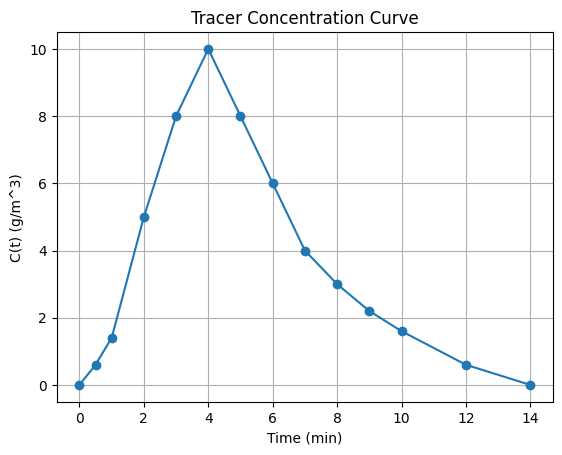

In [ ]:
plt.plot(t,C,"o-")
plt.xlabel("Time (min)")
plt.ylabel("C(t) (g/m^3)")
plt.title("Tracer Concentration Curve")
plt.grid()
plt.show()

## Plot of $E(t)$

$$ E(t) = \frac{C(t)}{\int_0^\infty C(t) dt} $$

We already have $C(t)$. Use numerical integration to integrate it:

In [ ]:
intC = cumulative_trapezoid(C, t, initial=0)
print("Integral of C(t) dt =",intC)

Integral of C(t) dt = [ 0.    0.15  0.65  3.85 10.35 19.35 28.35 35.35 40.35 43.85 46.45 48.35
 50.55 51.15]


Now we can plot $E(t)$:

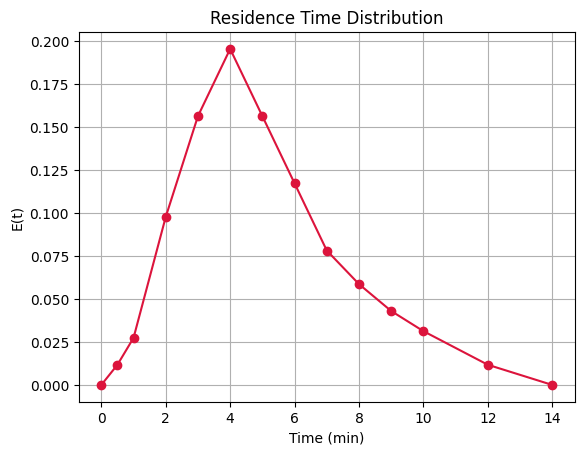

In [ ]:
E=C/intC[-1]
plt.plot(t, E, linestyle="-", marker="o", color="crimson", markerfacecolor="crimson", markeredgecolor="crimson")
plt.xlabel("Time (min)")
plt.ylabel("E(t)")
plt.title("Residence Time Distribution")
plt.grid()
plt.show()

In [ ]:
pd.DataFrame({"t (min)":t,"C (g/m^3)":C,"E (unitless)":E})

,t (min),C (g/m^3),E (unitless)
0,0.0,0.0,0.000000
1,0.5,0.6,0.011730
2,1.0,1.4,0.027370
3,2.0,5.0,0.097752
4,3.0,8.0,0.156403
5,4.0,10.0,0.195503
6,5.0,8.0,0.156403
7,6.0,6.0,0.117302
8,7.0,4.0,0.078201
9,8.0,3.0,0.058651


## Plot of $F(t)$

$$ F(t) = \int_0^t E(t) dt $$

And we plot it as a function of t. First, take the integral of $E(t)$:

In [ ]:
F = cumulative_trapezoid(E, t, initial=0)
print("F(t) =",F)

F(t) = [0.         0.00293255 0.01270772 0.07526882 0.20234604 0.37829912
 0.5542522  0.69110459 0.7888563  0.8572825  0.90811339 0.94525904
 0.98826979 1.        ]


In [ ]:
pd.DataFrame({"t (min)":t,"C (g/m^3)":C,"E (unitless)":E,"F (unitless)":F})

,t (min),C (g/m^3),E (unitless),F (unitless)
0,0.0,0.0,0.000000,0.000000
1,0.5,0.6,0.011730,0.002933
2,1.0,1.4,0.027370,0.012708
3,2.0,5.0,0.097752,0.075269
4,3.0,8.0,0.156403,0.202346
5,4.0,10.0,0.195503,0.378299
6,5.0,8.0,0.156403,0.554252
7,6.0,6.0,0.117302,0.691105
8,7.0,4.0,0.078201,0.788856
9,8.0,3.0,0.058651,0.857283


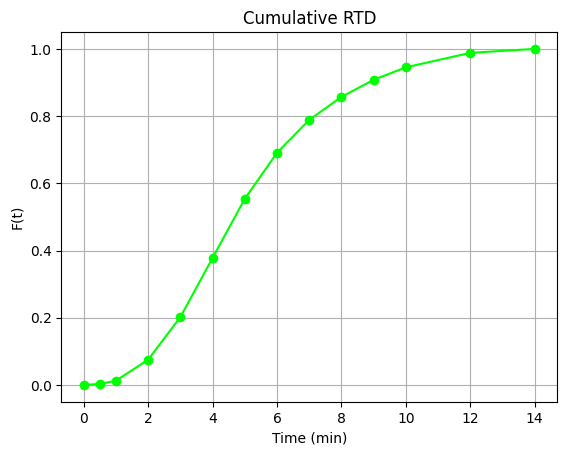

In [ ]:
plt.plot(t, F, linestyle="-", marker="o", color="lime", markerfacecolor="lime", markeredgecolor="lime")
plt.xlabel("Time (min)")
plt.ylabel("F(t)")
plt.title("Cumulative RTD")
plt.grid()
plt.show()

## mean residence time

$$t_m = \int_0^\infty tE(t) dt $$

First create a table of $tE(t)$:

In [ ]:
tEt = np.multiply(t,E)
pd.DataFrame({"t (min)":t,"C (g/m^3)":C,"E (unitless)":E,"F (unitless)":F,"t*E(t) (min)":tEt})

,t (min),C (g/m^3),E (unitless),F (unitless),t*E(t) (min)
0,0.0,0.0,0.000000,0.000000,0.000000
1,0.5,0.6,0.011730,0.002933,0.005865
2,1.0,1.4,0.027370,0.012708,0.027370
3,2.0,5.0,0.097752,0.075269,0.195503
4,3.0,8.0,0.156403,0.202346,0.469208
5,4.0,10.0,0.195503,0.378299,0.782014
6,5.0,8.0,0.156403,0.554252,0.782014
7,6.0,6.0,0.117302,0.691105,0.703812
8,7.0,4.0,0.078201,0.788856,0.547410
9,8.0,3.0,0.058651,0.857283,0.469208


In [ ]:
tm=cumulative_trapezoid(tEt,t,initial=0)
print(f"Mean residence time = {tm[-1]:.2f} min")

Mean residence time = 5.11 min


## Fraction of fluid that spends between 3 and 6 minutes in the reactor

This equals $\int_3^6 E(t) dt = F(6) - F(3) $:

In [ ]:
idx_3 = np.where(t == 3)[0][0]
idx_6 = np.where(t == 6)[0][0]

F_difference = F[idx_6] - F[idx_3]

print(f"F(6 min) - F(3 min) = {F_difference:.2f}")

F(6 min) - F(3 min) = 0.49


# Computing X using different reactor models

The reaction is 2A $\longrightarrow$ B. It exhibits elementary kinetics with $k$ = 0.1 m$^3$/ kmol / min and $C_{A0}$ = 1 kmol/m$^3$.

Hence:

$$-r_A = kC_A^2$$

Since this is a liquid phase reaction, $C_A = C_{A0}(1-X) $

Hence,

$$-r_A = k C_{A0}^2(1-X)^2 $$

## CSTR

$$ V = \frac{F_{A0}X}{-r_A} $$

Hence,

$$V = \frac{F_{A0}X}{kC_{A0}^2(1-X)^2} = \frac{C_{A0}\upsilon_0 X}{kC_{A0}^2(1-X)^2} = \frac{\upsilon_0 X}{kC_{A0}(1-X)^2} $$

Hence,

$$\tau = \frac{X}{kC_{A0}(1-X)^2} $$

For the CSTR and PFR, use $\tau$ = 5.11 min$^{-1}$.

Use the quadratic formula:

$$X = \frac{2\tau k C_{A0} + 1 - \left(4\tau k C_{A0} + 1\right)^{0.5}}{2\tau k C_{A0}} $$

In [ ]:
k = 0.1
CA0 = 1
X_CSTR = (2*tm[-1]*k*CA0 + 1 - (4*tm[-1]*k*CA0 + 1)**0.5)/(2*tm[-1]*k*CA0)
print(f"X = {X_CSTR:.4f}")

X = 0.2713


## PFR

$$ \frac{dX}{dV} = \frac{-r_A}{F_{A0}} = \frac{kC_{A0}^2(1-X)^2}{F_{A0}} = \frac{kC_{A0}(1-X)^2}{\upsilon_0} $$

Therefore,

$$\frac{dX}{d\tau} = kC_{A0}(1-X)^2 $$

So,

$$\int_0^X \frac{dX}{(1-X)^2} = kC_{A0}\tau $$

Therefore

$$kC_{A0}\tau = \frac{X}{1-X} $$

So

$$X = \frac{kC_{A0}\tau}{1+kC_{A0}\tau} $$

In [ ]:
X_PFR = k*CA0*tm[-1]/(1+k*CA0*tm[-1])
print(f"X = {X_PFR:.4f}")

X = 0.3382


## Segregation model

For the segregation model:

$$\bar{X} = \int_0^\infty X(t)E(t) dt $$

where $X(t)$ comes from the batch reactor mole balance. To get $X(t)$, solve the batch reactor mole balance:

$$\frac{dX}{dt} = \frac{-r_A}{C_{A0}} = \frac{kC_{A0}^2(1-X)^2}{C_{A0}} = kC_{A0}(1-X)^2 $$

Integrate to get $X(t)$:

$$\int_0^X \frac{dX}{(1-X)^2} = kC_{A0}t $$

Therefore:

$$\frac{X}{1-X} = kC_{A0}t $$

So

$$X(t) = \frac{kC_{A0}t}{1+kC_{A0}t} $$

Create a new column in our table:

In [ ]:
def X_batch(t, CA0, k):
  return k*CA0*t/(1+k*CA0*t)

X_batch = X_batch(t, CA0, k)
XtEt = np.multiply(X_batch,E)
pd.DataFrame({"t (min)":t,"C (g/m^3)":C,"E (unitless)":E,"F (unitless)":F,"t*E(t) (min)":tEt,"X(t)*E(t) (unitless)":XtEt})

,t (min),C (g/m^3),E (unitless),F (unitless),t*E(t) (min),X(t)*E(t) (unitless)
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.5,0.6,0.011730,0.002933,0.005865,0.000559
2,1.0,1.4,0.027370,0.012708,0.027370,0.002488
3,2.0,5.0,0.097752,0.075269,0.195503,0.016292
4,3.0,8.0,0.156403,0.202346,0.469208,0.036093
5,4.0,10.0,0.195503,0.378299,0.782014,0.055858
6,5.0,8.0,0.156403,0.554252,0.782014,0.052134
7,6.0,6.0,0.117302,0.691105,0.703812,0.043988
8,7.0,4.0,0.078201,0.788856,0.547410,0.032201
9,8.0,3.0,0.058651,0.857283,0.469208,0.026067


Integrate to get $X_{seg}$:

In [ ]:
X_seg=cumulative_trapezoid(XtEt,t,initial=0)
print(f"X = {X_seg[-1]:.4f}")

X = 0.3214


## Maximum mixedness model

For the maximum mixedness model,

$$\frac{dX}{dz} = \frac{-r_A}{C_{A0}} - \frac{E(\bar{T}-z)}{1-F(\bar{T}-z)}X $$

where $z = t$ and $\bar{T}$ = 14 min. To do this, we need to be able to evaluate $E(t)$ and $F(t)$ at any value of $t$. To do this, we could use interpolation or regression.

Interpolation is usually the better choice because it uses the data directly.

Normally we would use Lagrange polynomials, but they are "too big" for this problem. So, let's use a lower level of interpolation. (I find that linear and quadratic give the same result, so I'm going to use the simpler one.)

In [ ]:
# bounds_error = False prevents an error message if the solver goes out of bounds.
# fill_value = 0 means: if the solver goes out of bounds, the function value = 0.
# fill_value = (0,1) means: if the solver goes "to the left" of the initial value, set the function to 0, and if it goes "to the right" of the final value, set the function to 1.
E_func = interp1d(t, E, kind='linear', bounds_error=False, fill_value=0)
F_func = interp1d(t, F, kind='linear', bounds_error=False, fill_value=(0.0,1.0))

Now, we can write a function to solve the maxium mixedness model (feel free to adapt it "free of charge," i.e., without losing innovativeness points, in your in-class activity and practice problem solutions):

In [ ]:
def max_mixedness_ode(z, X):
  """
  z: independent variable (integrating backwards from 14 to 0)
  X: conversion array (solve_ivp expects a list/array)
  """
  time_arg = 14.0 - z  # Represents (\bar{T} - z)

  # Look up E and F values at the current time argument
  E_val = E_func(time_arg)
  F_val = F_func(time_arg)

  # rate term: -rA/CA0
  rate = k * CA0**2 * (1.0 - X[0])**2
  rate_term = rate / CA0

  # SAFETY: Prevent division by zero as F(t) approaches 1.0 at the end
  denom = 1.0 - F_val
  if denom < 1e-6:
      denom = 1e-6

  dXdz = rate_term - (E_val / denom) * X[0]
  return [dXdz]

z_span = (0.0, 14.0)
X_initial = [0.0]

sol = solve_ivp(max_mixedness_ode, z_span, X_initial, method='Radau')

X_mm = sol.y[0][-1]

print(f"X = {X_mm:.4f}")

X = 0.3169
